In [1]:
from datasets import load_dataset

/home/y/wsl_code/qwiglip_vlm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#load vqa dataset
dataset = load_dataset("landersanmi/VQAv2", split="train[:5000]")

print(dataset)


Dataset({
    features: ['image', 'question', 'answer', 'answer_type', 'choices'],
    num_rows: 5000
})


In [3]:
#sample
sample = dataset[0]

print(sample)

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=640x512 at 0x790A44638590>, 'question': '[QUESTION]Where is he looking?', 'answer': 'Down', 'answer_type': 'other', 'choices': '[OPTIONS](A) Up (B) Down (C) Down chicken sandwich (D) Out '}


In [ ]:
import os

# ensure the target directory exists before you start saving images
os.makedirs("vqa_images", exist_ok=True)


def convert_to_chat(sample, idx):
    #idx as unique path
    image_path = f"vqa_images/image_{idx}.jpg" 
    
    sample["image"].save(image_path)  
    
    return {
        "image_path": image_path,  
        "messages": [
            {
                "role": "user",
                "content": f"<image>\n{sample['question'].replace('[QUESTION]', '').strip()}"
            },
            {
                "role": "assistant",
                "content": sample["answer"].strip().capitalize() + "."
            }
        ]
    }

In [ ]:
#apply format
chat_dataset = dataset.map(convert_to_chat, with_indices=True)
chat_dataset[2]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]


KeyError: 'image_id'

<image>
Question: What is the man doing in the street?
Walking.


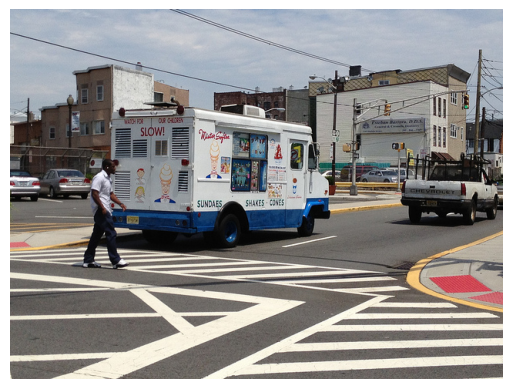

In [ ]:
#visualize sample
from PIL import Image
import matplotlib.pyplot as plt

sample = chat_dataset[2]

image = Image.open(sample['image_path'])
plt.imshow(image)
plt.axis("off")

print(sample["messages"][0]["content"])
print(sample["messages"][1]["content"])

In [29]:
#save dataset
chat_dataset.save_to_disk("vqa5k_chat_dataset")

Saving the dataset (5/5 shards): 100%|██████████| 5000/5000 [00:10<00:00, 464.26 examples/s]
